# Predicting Insurance Claim Amounts
## Introduction 
The goal is to predict medical insurance charges based on personal data such as age, BMI, smoking status, and other factors. We will use a Linear Regression model to estimate insurance claim amounts.

### Objective:
Train a Linear Regression model
Analyze impact of BMI, age, and smoking on charges
Evaluate model using MAE and RMSE

In [1]:
#Import Libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

#Dataset Load & Understanding.
df = pd.read_csv("insurance.csv")
df.head()

df.shape
df.info()
df.describe()

#Data Cleaning.
df.isnull().sum()
df.drop_duplicates(inplace=True)

#Convert Categorical Data.

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


# Exploratory Data Analysis (EDA)

## Correlation Heatmap

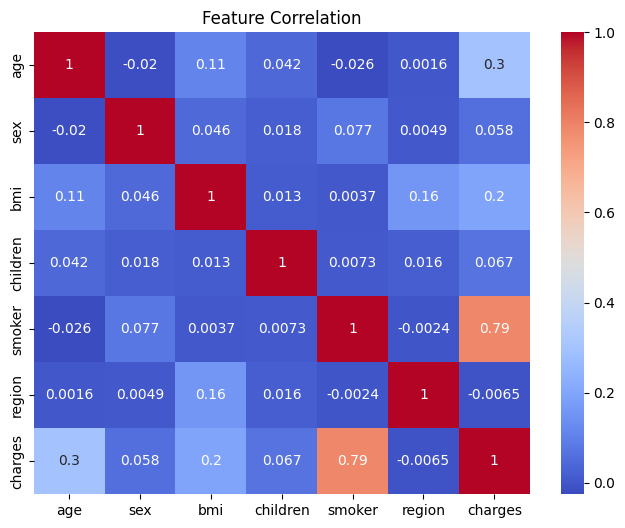

In [2]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## Age vs Charges

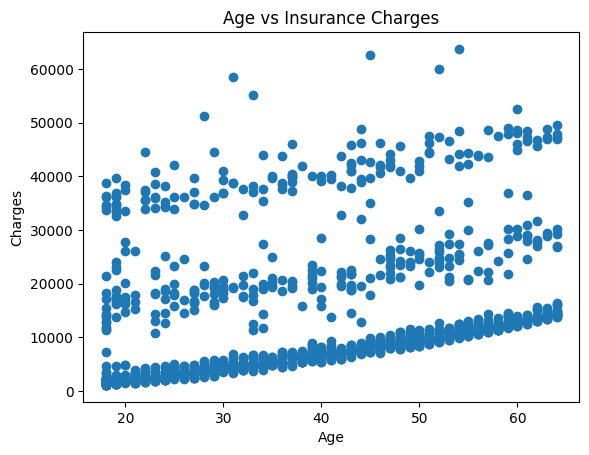

In [3]:
#Age vs Charges
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Insurance Charges")
plt.show()

## BMI vs Charges

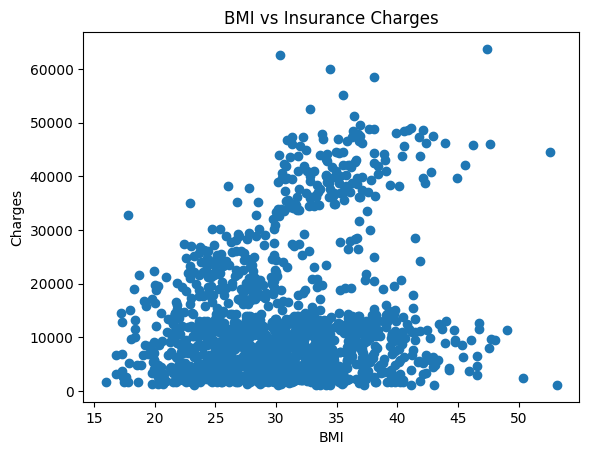

In [4]:
#BMI vs Charges
plt.scatter(df['bmi'], df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

## Smoking Impact on Charges

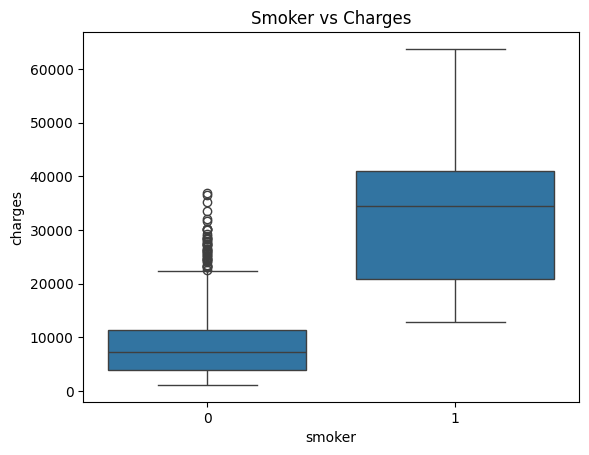

In [5]:
#Smoking Impact on Charges
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

## Actual vs Predicted

MAE: 4182.353155288297
RMSE: 5957.60879981646


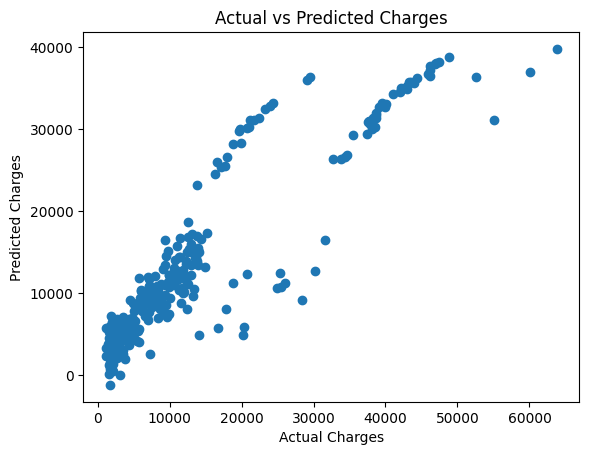

In [13]:
#Train Test Split
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

#Model Evaluation

#MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

#RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

#Actual vs Predicted Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

## Key Insights:
Smoking has the strongest impact on insurance charges
Higher BMI increases medical costs
Age also increases insurance charges gradually
Linear Regression provides a basic but effective prediction model

## Conclusion:

In this project we successfully built a Linear Regression model to predict insurance charges. After preprocessing and encoding categorical variables. we trained the model and evaluated it using MAE and RMSE. Visualization helped us understand that smoking status, BMI and age significantly affect insurance costs.